In [1]:
import pandas as pd
from astroquery.gaia import Gaia
import os

print("🚀 Connexion aux serveurs de l'ESA (Gaia DR3)...")

# 1. Requête ADQL : On exige cette fois que 'radial_velocity' NE SOIT PAS NULLE
query = """
SELECT TOP 100000 
    source_id, ra, dec, 
    parallax, parallax_error, 
    pmra, pmra_error, pmdec, pmdec_error,
    phot_g_mean_mag, bp_rp,
    radial_velocity, radial_velocity_error
FROM gaiadr3.gaia_source 
WHERE parallax IS NOT NULL 
  AND pmra IS NOT NULL 
  AND pmdec IS NOT NULL
  AND phot_g_mean_mag IS NOT NULL
  AND radial_velocity IS NOT NULL
"""

# 2. Exécution et récupération
job = Gaia.launch_job(query)
results = job.get_results()

# 3. Conversion en DataFrame
df_rv = results.to_pandas()
print(f"✅ Téléchargement terminé : {len(df_rv)} étoiles récupérées avec leur vitesse radiale.")

# 4. Sauvegarde dans le même dossier 'data' que le projet précédent
dossier_data = r"data"
if not os.path.exists(dossier_data):
    os.makedirs(dossier_data)

chemin_fichier = os.path.join(dossier_data, "gaia_rv_train_100k.parquet")
df_rv.to_parquet(chemin_fichier, index=False)
print(f"💾 Données sauvegardées avec succès dans : {chemin_fichier}\n")

# 5. Affichage pour vérification
display(df_rv.head())

Some IP addresses of users launching heavy query showers have temporarily been disabled. Please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk) for advice. Workaround solutions for the Gaia Archive issues following the infrastructure upgrade: https://www.cosmos.esa.int/web/gaia/news#WorkaroundArchive
🚀 Connexion aux serveurs de l'ESA (Gaia DR3)...
✅ Téléchargement terminé : 100000 étoiles récupérées avec leur vitesse radiale.
💾 Données sauvegardées avec succès dans : data\gaia_rv_train_100k.parquet



,source_id,ra,dec,parallax,parallax_error,pmra,pmra_error,pmdec,pmdec_error,phot_g_mean_mag,bp_rp,radial_velocity,radial_velocity_error
0,16870631694208,45.112778,0.380840,2.101317,0.017279,-0.969421,0.017739,-12.268805,0.014436,10.629925,0.838217,1.829347,0.473879
1,33264522507136,44.974662,0.473465,1.402974,0.015528,10.420200,0.016957,-24.870877,0.012939,9.887423,1.226941,17.182444,0.167765
2,44358422235136,45.501454,0.497697,9.558267,0.018802,25.169367,0.017925,-23.702794,0.019756,9.365663,0.827668,40.746841,0.289030
3,49001282700416,45.463083,0.577321,0.948748,0.018475,15.241354,0.019024,-14.684064,0.017815,13.874384,1.160342,-89.274269,3.574905
4,72915660589952,44.702648,0.402698,1.460941,0.027891,13.778210,0.032650,-2.941163,0.023505,9.842077,1.258080,44.032558,0.207912


In [2]:
import numpy as np

print("⚙️ Démarrage du Feature Engineering...")

# 1. Nettoyage initial : On enlève les parallaxes négatives ou nulles 
# (ce sont des erreurs de mesure de Gaia qui rendraient les distances infinies)
df_clean = df_rv[df_rv['parallax'] > 0].copy()

# 2. Création des nouvelles variables physiques
# Distance en parsecs
df_clean['distance_pc'] = 1000 / df_clean['parallax']

# Magnitude Absolue (la vraie puissance lumineuse de l'étoile)
df_clean['absolute_mag'] = df_clean['phot_g_mean_mag'] - 5 * np.log10(df_clean['distance_pc']) + 5

# Mouvement propre total (la flèche de vitesse 2D)
df_clean['pm_total'] = np.sqrt(df_clean['pmra']**2 + df_clean['pmdec']**2)

# 3. Sélection des "Features" (X) et de la "Target" (y)
features_columns = [
    'parallax', 'pmra', 'pmdec', 'phot_g_mean_mag', 'bp_rp', 
    'distance_pc', 'absolute_mag', 'pm_total'
]

# On retire les éventuels NaN créés pendant les calculs
df_clean = df_clean.dropna(subset=features_columns + ['radial_velocity'])

X = df_clean[features_columns]
y = df_clean['radial_velocity'] # Ce que l'IA doit deviner !
y_error_true = df_clean['radial_velocity_error'] # On garde ça de côté pour la fin

print(f"✅ Feature Engineering terminé ! Il reste {len(df_clean)} étoiles valides.")
print(f"📊 Nombre de variables d'entrée (Features) : {X.shape[1]}")

display(X.head())

⚙️ Démarrage du Feature Engineering...
✅ Feature Engineering terminé ! Il reste 99461 étoiles valides.
📊 Nombre de variables d'entrée (Features) : 8


,parallax,pmra,pmdec,phot_g_mean_mag,bp_rp,distance_pc,absolute_mag,pm_total
0,2.101317,-0.969421,-12.268805,10.629925,0.838217,475.891970,2.242383,12.307045
1,1.402974,10.420200,-24.870877,9.887423,1.226941,712.771648,0.622670,26.965554
2,9.558267,25.169367,-23.702794,9.365663,0.827668,104.621473,4.267558,34.573393
3,0.948748,15.241354,-14.684064,13.874384,1.160342,1054.020455,3.760139,21.164135
4,1.460941,13.778210,-2.941163,9.842077,1.258080,684.490505,0.665240,14.088631


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

print("Préparation des Tensors et du Réseau de Neurones...")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=256, shuffle=False)

print(f"Données prêtes ! {len(X_train)} étoiles pour l'entraînement, {len(X_test)} pour l'examen.")

class MCDropoutNet(nn.Module):
    def __init__(self, input_dim=8):
        super(MCDropoutNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc_out = nn.Linear(64, 1)
        self.dropout = nn.Dropout(p=0.2)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.relu(self.fc3(x))
        x = self.dropout(x)
        return self.fc_out(x)

model_mc = MCDropoutNet()
print("Architecture MCDropoutNet créée avec succès !")
print(model_mc)

Préparation des Tensors et du Réseau de Neurones...
Données prêtes ! 79568 étoiles pour l'entraînement, 19893 pour l'examen.
Architecture MCDropoutNet créée avec succès !
MCDropoutNet(
  (fc1): Linear(in_features=8, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=64, bias=True)
  (fc_out): Linear(in_features=64, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (relu): ReLU()
)


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Entraînement lancé sur : {device}")

model_mc.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model_mc.parameters(), lr=0.005)

epochs = 30
print("⏳ Début de la phase d'apprentissage...")

for epoch in range(epochs):
    model_mc.train()
    running_loss = 0.0

    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model_mc(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        avg_loss = running_loss/len(train_loader)
        print(f"Epoch {epoch+1}/{epochs} - Erreur moyenne (MSE): {avg_loss:.2f}")

print("✅ Entraînement terminé avec succès !")

🚀 Entraînement lancé sur : cuda
⏳ Début de la phase d'apprentissage...
Epoch 5/30 - Erreur moyenne (MSE): 1119.39
Epoch 10/30 - Erreur moyenne (MSE): 1121.87
Epoch 15/30 - Erreur moyenne (MSE): 1102.73
Epoch 20/30 - Erreur moyenne (MSE): 1096.90
Epoch 25/30 - Erreur moyenne (MSE): 1093.71
Epoch 30/30 - Erreur moyenne (MSE): 1097.95
✅ Entraînement terminé avec succès !


🔮 Lancement des prédictions avec Incertitude (Monte Carlo Dropout)...
📊 Création du graphique...


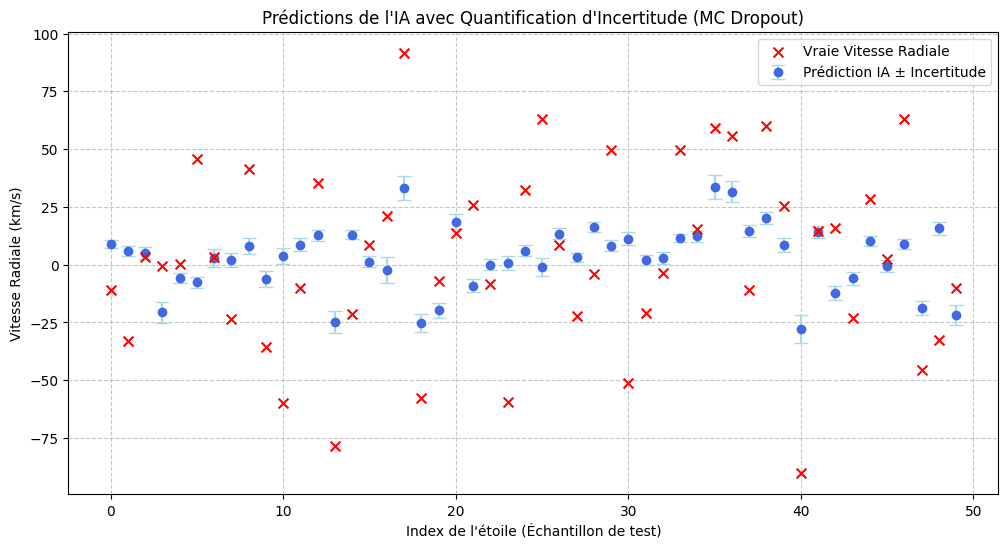

In [12]:
import matplotlib.pyplot as plt
import numpy as np

print("🔮 Lancement des prédictions avec Incertitude (Monte Carlo Dropout)...")


model_mc.train()

X_sample = X_test_tensor[:50].to(device)
y_sample_true = y_test_tensor[:50].cpu().numpy()

T = 100  # On demande 100 fois son avis à l'IA pour chaque étoile
predictions = torch.zeros(T, len(X_sample))

with torch.no_grad():
    for t in range(T):
        preds = model_mc(X_sample)
        predictions[t] = preds.squeeze().cpu()
 
mean_preds = predictions.mean(dim=0).numpy()
std_preds = predictions.std(dim=0).numpy()

print("📊 Création du graphique...")
plt.figure(figsize=(12, 6))

plt.errorbar(range(50), mean_preds, yerr=std_preds, fmt='o', color='royalblue', ecolor='lightblue', capsize=5, label='Prédiction IA ± Incertitude')

plt.scatter(range(50), y_sample_true, color='red', marker='x', s=50, label='Vraie Vitesse Radiale', zorder=5)

plt.xlabel("Index de l'étoile (Échantillon de test)")
plt.ylabel("Vitesse Radiale (km/s)")
plt.title("Prédictions de l'IA avec Quantification d'Incertitude (MC Dropout)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()